In [1]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# input from ISARCASM
df = pd.read_csv("./iSarcasmEval/train/train.En.csv")
df = df.dropna(subset=["tweet", "sarcastic"])

analyzer = SentimentIntensityAnalyzer()

# use vader sentiment to calculate sentiment score for each tweet from the ISARCASM dataset
def surface(t): 
    return analyzer.polarity_scores(str(t))["compound"]

# grabbing Sarcastic Texts
sarc_texts = df[df['sarcastic'] == 1]['tweet'].tolist()

# Producing the Paired Control (Topic-Matched Sincere) of the sarcastic dataset
paired_nonsarc_texts = df[df['sarcastic'] == 1]['rephrase'].dropna().tolist()

# The Baseline Control (Naturally Sincere)
baseline_nonsarc_texts = df[df['sarcastic'] == 0]['tweet'].dropna().tolist()

# creating the matrix
classes = {
    # Sarcastic
    "sarcastic_surfpos":       [t for t in sarc_texts if surface(t) > 0.3],
    "sarcastic_surfneg":       [t for t in sarc_texts if surface(t) < -0.3],
    
    # Paired Sincere (The perfect mathematical control)
    "paired_sincere_pos":      [t for t in paired_nonsarc_texts if surface(t) > 0.3],
    "paired_sincere_neg":      [t for t in paired_nonsarc_texts if surface(t) < -0.3],
    
    # Baseline Sincere (The natural distribution)
    "baseline_sincere_pos":    [t for t in baseline_nonsarc_texts if surface(t) > 0.3],
    "baseline_sincere_neg":    [t for t in baseline_nonsarc_texts if surface(t) < -0.3],
}

# Display counts
for k, v in classes.items(): 
    print(f"{k}: {len(v)}")


sarcastic_surfpos: 410
sarcastic_surfneg: 144
paired_sincere_pos: 208
paired_sincere_neg: 288
baseline_sincere_pos: 1101
baseline_sincere_neg: 541


In [2]:
from huggingface_hub import login

login(token="REDACTED")


In [3]:
!nvidia-smi

Thu Jul  9 11:50:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:C1:00.0 Off |                  N/A |
|  0%   36C    P8             28W /  250W |       1MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:

import torch
from transformer_lens import HookedTransformer
import numpy as np
import matplotlib.pyplot as plt

device = "cuda"
torch.cuda.empty_cache()
import gc
gc.collect()

model = HookedTransformer.from_pretrained("gemma-2-2b", device=device)
model.eval()
N_LAYERS = model.cfg.n_layers


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model gemma-2-2b into HookedTransformer


In [4]:
# Phase 0a: Extract residual stream activations
def get_resid_acts(texts, batch_size=16):
    """Returns dict: layer -> tensor [n_texts, d_model] of last-token resid_post."""
    acts = {l: [] for l in range(N_LAYERS)}
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        tokens = model.to_tokens(batch)
        last_idx = (tokens != model.tokenizer.pad_token_id).sum(dim=1) - 1
        with torch.no_grad():
            _, cache = model.run_with_cache(
                tokens,
                names_filter=lambda n: n.endswith("hook_resid_post")
            )
        for l in range(N_LAYERS):
            resid = cache[f"blocks.{l}.hook_resid_post"]
            acts[l].append(resid[torch.arange(len(batch)), last_idx].cpu())
        del cache
    return {l: torch.cat(v) for l, v in acts.items()}

In [5]:

# Phase 0b: Build sentiment direction
pos_texts = classes["baseline_sincere_pos"][:300]  # use 300 for speed
neg_texts = classes["baseline_sincere_neg"][:300]


In [6]:

pos_acts = get_resid_acts(pos_texts)
print("done")
neg_acts = get_resid_acts(neg_texts)


done


In [7]:

sentiment_dir = {}
for l in range(N_LAYERS):
    d = pos_acts[l].mean(0) - neg_acts[l].mean(0)
    sentiment_dir[l] = d / d.norm()


In [8]:

# Phase 0c: Sanity check - held-out test set
pos_test = get_resid_acts(classes["baseline_sincere_pos"][300:450])
neg_test = get_resid_acts(classes["baseline_sincere_neg"][300:400])


In [ ]:

# Check separation at each layer
separations = []
for l in range(N_LAYERS):
    p = pos_test[l] @ sentiment_dir[l]   # projections
    n = neg_test[l] @ sentiment_dir[l]
    gap = (p.mean() - n.mean()) / torch.cat([p, n]).std()
    separations.append(gap.item())


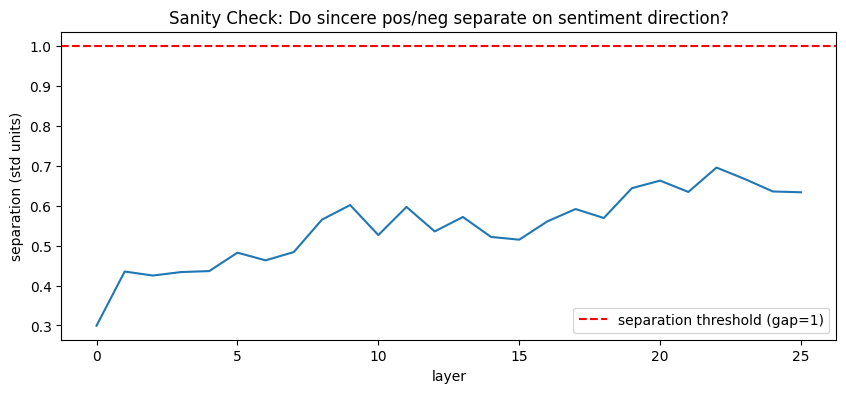

Separation by layer:
  layer 5: 0.48
  layer 10: 0.53
  layer 15: 0.51
  layer 20: 0.66
  layer 25: 0.63

:x: KILL SWITCH: Sentiment direction doesn't separate sincere texts. Pipeline broken.
Debug: check tokenization, padding, layer choice, or data quality.


In [10]:

# Plot it
plt.figure(figsize=(10, 4))
plt.plot(separations)
plt.axhline(1, color='r', linestyle='--', label='separation threshold (gap=1)')
plt.xlabel("layer")
plt.ylabel("separation (std units)")
plt.title("Sanity Check: Do sincere pos/neg separate on sentiment direction?")
plt.legend()
plt.savefig("sanity_check.png")
plt.show()

# Print key layers
print("Separation by layer:")
for l in [5, 10, 15, 20, 25]:
    print(f"  layer {l}: {separations[l]:.2f}")

# Kill switch
if max(separations[5:25]) < 1.0:
    print("\n:x: KILL SWITCH: Sentiment direction doesn't separate sincere texts. Pipeline broken.")
    print("Debug: check tokenization, padding, layer choice, or data quality.")
else:
    print(f"\n✓ PASS: Best separation {max(separations[5:25]):.2f} at layer {np.argmax(separations[5:25]) + 5}")
